In [1]:
from utils.random_forest_utils.rf_preprocessing_utils import WindowAlgPreprocessor

rf_preprocessor = WindowAlgPreprocessor(sensors_path="../../../../data/ml/features_machine_and_movement_complete.csv", target_path="../../../../data/ml/targets_movement_complete.csv")
sensors_df, target_df = rf_preprocessor.read_data()
sensors_df = rf_preprocessor.feature_selection()
rf_preprocessor.normalize_angle()

,Experiment_ID,Angle[degree]ORDistance[mm],Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
0,2,0.000000,0.317461,0.337050,0.626034,0.344543
1,2,0.022017,0.319825,0.363018,0.600159,0.372211
2,2,0.044033,0.319035,0.401244,0.560835,0.412939
3,2,0.066050,0.317768,0.438220,0.522651,0.452336
4,2,0.088067,0.320230,0.465094,0.495879,0.480970
...,...,...,...,...,...,...
14558,318,0.902686,0.641596,0.373375,0.680266,0.314326
14559,318,0.924703,0.640550,0.372634,0.680719,0.313536
14560,318,0.946720,0.640334,0.374073,0.679194,0.315070
14561,318,0.968736,0.641037,0.377992,0.675413,0.319245


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

class TimeSeriesRegressor(nn.Module):
    def __init__(self, input_size=16, seq_len=200, hidden_size=128, output_size=4, lr=1e-3):
        super(TimeSeriesRegressor, self).__init__()
        
        self.seq_len = seq_len
        self.input_size = input_size
        
        # Fully connected feedforward layers
        self.fc1 = nn.Linear(seq_len * input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size // 2, output_size)
        
        # Loss and optimizer
        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(self.parameters(), lr=lr)

    def forward(self, x):
        # Flatten the time and feature dimensions
        x = x.view(x.size(0), -1)  # shape: (batch, seq_len * features)
        
        # Forward pass through dense layers
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

    def train_model(self, X, Y, epochs=30, batch_size=16):
        dataset = torch.utils.data.TensorDataset(X, Y)
        loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
        last_loss = None
        
        for epoch in range(epochs):
            epoch_loss = 0
            for x_batch, y_batch in loader:
                self.optimizer.zero_grad()
                outputs = self.forward(x_batch)
                loss = self.criterion(outputs, y_batch)
                loss.backward()
                self.optimizer.step()
                epoch_loss += loss.item()
            last_loss = epoch_loss / len(loader)
            print(f"Epoch {epoch+1}/{epochs} - Loss: {last_loss:.6f}")
        return last_loss


Epoch [1/100] Train Loss: 0.070465 | Val Loss: 0.018024
Epoch [2/100] Train Loss: 0.015380 | Val Loss: 0.011015
Epoch [3/100] Train Loss: 0.010371 | Val Loss: 0.006415
Epoch [4/100] Train Loss: 0.007174 | Val Loss: 0.004774
Epoch [5/100] Train Loss: 0.004805 | Val Loss: 0.003532
Epoch [6/100] Train Loss: 0.003598 | Val Loss: 0.002884
Epoch [7/100] Train Loss: 0.002966 | Val Loss: 0.003619
Epoch [8/100] Train Loss: 0.002725 | Val Loss: 0.003645
Epoch [9/100] Train Loss: 0.002869 | Val Loss: 0.002782
Epoch [10/100] Train Loss: 0.002321 | Val Loss: 0.002461
Epoch [11/100] Train Loss: 0.002471 | Val Loss: 0.002448
Epoch [12/100] Train Loss: 0.002155 | Val Loss: 0.002600
Epoch [13/100] Train Loss: 0.002195 | Val Loss: 0.001868
Epoch [14/100] Train Loss: 0.002114 | Val Loss: 0.002292
Epoch [15/100] Train Loss: 0.002374 | Val Loss: 0.002134
Epoch [16/100] Train Loss: 0.002138 | Val Loss: 0.002180
Epoch [17/100] Train Loss: 0.002256 | Val Loss: 0.002969
Epoch [18/100] Train Loss: 0.002274 | Va

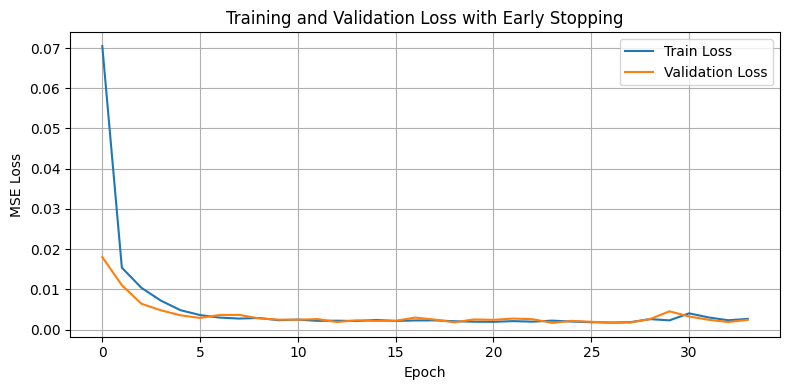

In [3]:
import torch
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# 1️⃣ Load data
# -------------------------------
X = rf_preprocessor.group_and_pad(
    rf_preprocessor.sensor_df, group_col="Experiment_ID"
)[70:, :, :]  # shape: (samples, timesteps, features)

Y = rf_preprocessor.group_and_pad(
    rf_preprocessor.target_df, group_col="Experiment_ID"
)[70:, 20:21, :]  # shape: (samples, 1, output_features)

# -------------------------------
# 2️⃣ Split into train, val, test
# -------------------------------
X_temp, X_test, Y_temp, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, shuffle=True
)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_temp, Y_temp, test_size=0.25, random_state=42, shuffle=True
)

# -------------------------------
# 3️⃣ Convert to torch tensors
# -------------------------------
X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32).squeeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
Y_val_t = torch.tensor(Y_val, dtype=torch.float32).squeeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
Y_test_t = torch.tensor(Y_test, dtype=torch.float32).squeeze(1)

# -------------------------------
# 4️⃣ Initialize model
# -------------------------------
model = TimeSeriesRegressor(
    input_size=X.shape[-1],
    seq_len=X.shape[1],
    hidden_size=128,  # match model default
    output_size=Y.shape[-1],
    lr=1e-4
)

optimizer = model.optimizer  # use model's optimizer
criterion = model.criterion  # use model's criterion

# -------------------------------
# 5️⃣ Training loop with validation and early stopping
# -------------------------------
epochs = 100
batch_size = 16
patience = 10
best_val_loss = np.inf
no_improve_count = 0

train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0.0

    # Shuffle batch indices
    permutation = torch.randperm(X_train_t.size(0))
    for i in range(0, X_train_t.size(0), batch_size):
        indices = permutation[i:i + batch_size]
        X_batch, Y_batch = X_train_t[indices], Y_train_t[indices]

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, Y_batch)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

    epoch_train_loss /= (X_train_t.size(0) / batch_size)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        Y_val_pred = model(X_val_t)
        val_loss = criterion(Y_val_pred, Y_val_t).item()
        val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {epoch_train_loss:.6f} | Val Loss: {val_loss:.6f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve_count = 0
        best_model_state = model.state_dict()
    else:
        no_improve_count += 1
        if no_improve_count >= patience:
            print(f"🛑 Early stopping at epoch {epoch+1}")
            break

# -------------------------------
# 6️⃣ Load best model
# -------------------------------
model.load_state_dict(best_model_state)

# -------------------------------
# 7️⃣ Evaluate on test set
# -------------------------------
model.eval()
with torch.no_grad():
    Y_pred_test = model(X_test_t)
    test_mse = criterion(Y_pred_test, Y_test_t).item()

print(f"\n📊 Final Results:")
print(f"   🟩 Best Validation MSE = {best_val_loss:.6f}")
print(f"   🟥 Test MSE = {test_mse:.6f}")

# -------------------------------
# 8️⃣ Plot training & validation loss
# -------------------------------
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss with Early Stopping")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Base test MSE: 0.00214876
Window  108 → masked MSE: 0.0111642294, ΔMSE: 0.0090154677
Window  216 → masked MSE: 0.0115016503, ΔMSE: 0.0093528887
Window  324 → masked MSE: 0.0106437188, ΔMSE: 0.0084949571
Window  432 → masked MSE: 0.0095278723, ΔMSE: 0.0073791107
Window  540 → masked MSE: 0.0097772293, ΔMSE: 0.0076284676
Window  648 → masked MSE: 0.0089429850, ΔMSE: 0.0067942233
Window  756 → masked MSE: 0.0077254376, ΔMSE: 0.0055766760
Window  864 → masked MSE: 0.0081810681, ΔMSE: 0.0060323065
Window  972 → masked MSE: 0.0086924713, ΔMSE: 0.0065437097
Window 1080 → masked MSE: 0.0076665012, ΔMSE: 0.0055177396
Window 1188 → masked MSE: 0.0060278052, ΔMSE: 0.0038790435
Window 1296 → masked MSE: 0.0068080337, ΔMSE: 0.0046592720
Window 1404 → masked MSE: 0.0097853625, ΔMSE: 0.0076366009
Window 1512 → masked MSE: 0.0099741714, ΔMSE: 0.0078254098
Window 1620 → masked MSE: 0.0079815006, ΔMSE: 0.0058327389


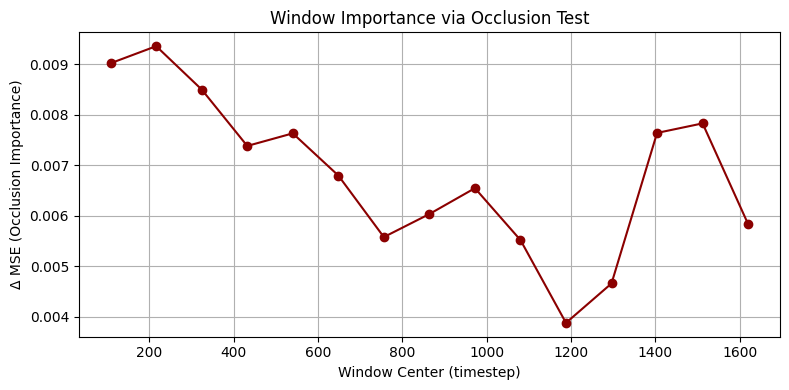

In [4]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# -------------------------------
# 1️⃣ Define occlusion window parameters
# -------------------------------
seq_len = X_test_t.shape[1]

# Use larger windows: e.g., 20% of sequence length
patch_size = seq_len // 8  
step = patch_size // 2

window_centers = list(range(patch_size // 2, seq_len - patch_size // 2 + 1, step))

# -------------------------------
# 2️⃣ Compute base prediction
# -------------------------------
model.eval()
with torch.no_grad():
    base_pred = model(X_test_t)
    base_loss = F.mse_loss(base_pred, Y_test_t).item()

print(f"\nBase test MSE: {base_loss:.8f}")

# -------------------------------
# 3️⃣ Occlusion importance
# -------------------------------
importance_scores, window_positions = [], []

with torch.no_grad():
    for center in window_centers:
        start = center - patch_size // 2
        end = center + patch_size // 2
        if end > seq_len:
            continue

        X_masked = X_test_t.clone()
        # Mask with zeros (or mean values for smoother effect)
        X_masked[:, start:end, :] = 0  

        masked_pred = model(X_masked)
        masked_loss = F.mse_loss(masked_pred, Y_test_t).item()

        delta_loss = masked_loss - base_loss
        importance_scores.append(delta_loss)
        window_positions.append(center)

        print(f"Window {center:4d} → masked MSE: {masked_loss:.10f}, ΔMSE: {delta_loss:.10f}")

# -------------------------------
# 4️⃣ Plot results
# -------------------------------
plt.figure(figsize=(8, 4))
plt.plot(window_positions, importance_scores, marker='o', color='darkred')
plt.xlabel("Window Center (timestep)")
plt.ylabel("Δ MSE (Occlusion Importance)")
plt.title("Window Importance via Occlusion Test")
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

class TimeSeriesCNN(nn.Module):
    def __init__(self, input_size=16, seq_len=2000, hidden_channels=64, output_size=4, lr=1e-3):
        super(TimeSeriesCNN, self).__init__()
        
        self.seq_len = seq_len
        self.input_size = input_size
        
        # 1D Convolution layers
        self.conv1 = nn.Conv1d(in_channels=input_size, out_channels=hidden_channels, kernel_size=5, padding=2)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(in_channels=hidden_channels, out_channels=hidden_channels, kernel_size=5, padding=2)
        self.relu2 = nn.ReLU()
        
        # Global average pooling
        self.pool = nn.AdaptiveAvgPool1d(1)
        
        # Fully connected output
        self.fc = nn.Linear(hidden_channels, output_size)
        
        # Loss and optimizer
        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(self.parameters(), lr=lr)
    
    def forward(self, x):
        # x shape: (batch, seq_len, input_size) → transpose to (batch, input_size, seq_len)
        x = x.transpose(1, 2)
        
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        
        # Global average pooling over the sequence
        x = self.pool(x).squeeze(-1)
        
        # Fully connected output
        out = self.fc(x)
        return out
    
    def train_model(self, X, Y, epochs=30, batch_size=16):
        dataset = torch.utils.data.TensorDataset(X, Y)
        loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
        last_loss = None
        
        for epoch in range(epochs):
            epoch_loss = 0
            self.train()
            for x_batch, y_batch in loader:
                self.optimizer.zero_grad()
                outputs = self.forward(x_batch)
                loss = self.criterion(outputs, y_batch)
                loss.backward()
                self.optimizer.step()
                epoch_loss += loss.item()
            last_loss = epoch_loss / len(loader)
            print(f"Epoch {epoch+1}/{epochs} - Loss: {last_loss:.6f}")
        return last_loss


Epoch [1/100] Train Loss: 0.237307 | Val Loss: 0.194954
Epoch [2/100] Train Loss: 0.188081 | Val Loss: 0.154459
Epoch [3/100] Train Loss: 0.145322 | Val Loss: 0.114179
Epoch [4/100] Train Loss: 0.104189 | Val Loss: 0.074332
Epoch [5/100] Train Loss: 0.063050 | Val Loss: 0.041622
Epoch [6/100] Train Loss: 0.032063 | Val Loss: 0.023056
Epoch [7/100] Train Loss: 0.019056 | Val Loss: 0.016526
Epoch [8/100] Train Loss: 0.016798 | Val Loss: 0.014663
Epoch [9/100] Train Loss: 0.015295 | Val Loss: 0.014397
Epoch [10/100] Train Loss: 0.014305 | Val Loss: 0.014282
Epoch [11/100] Train Loss: 0.014786 | Val Loss: 0.014179
Epoch [12/100] Train Loss: 0.013864 | Val Loss: 0.014195
Epoch [13/100] Train Loss: 0.013645 | Val Loss: 0.014178
Epoch [14/100] Train Loss: 0.014046 | Val Loss: 0.014175
Epoch [15/100] Train Loss: 0.015581 | Val Loss: 0.014120
Epoch [16/100] Train Loss: 0.014258 | Val Loss: 0.014125
Epoch [17/100] Train Loss: 0.013576 | Val Loss: 0.014074
Epoch [18/100] Train Loss: 0.014341 | Va

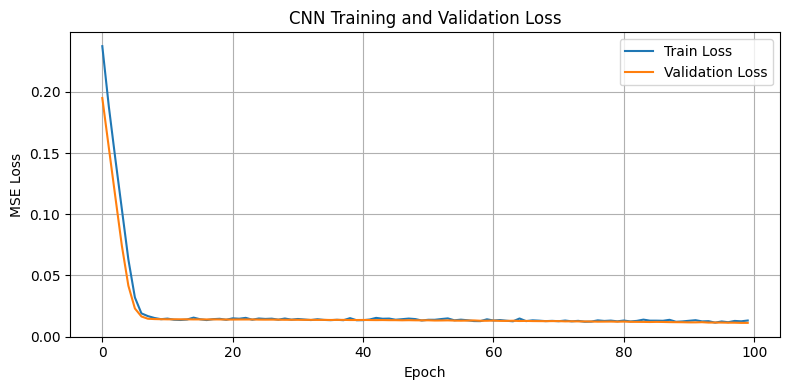


Base test MSE: 0.01290142
Window  174 → masked MSE: 0.0220695995, ΔMSE: 0.0091681760
Window  348 → masked MSE: 0.0228620544, ΔMSE: 0.0099606309
Window  522 → masked MSE: 0.0234781802, ΔMSE: 0.0105767567
Window  696 → masked MSE: 0.0238596369, ΔMSE: 0.0109582134
Window  870 → masked MSE: 0.0232720096, ΔMSE: 0.0103705861
Window 1044 → masked MSE: 0.0225281883, ΔMSE: 0.0096267648
Window 1218 → masked MSE: 0.0211219117, ΔMSE: 0.0082204882
Window 1392 → masked MSE: 0.0208146181, ΔMSE: 0.0079131946
Window 1566 → masked MSE: 0.0208838582, ΔMSE: 0.0079824347


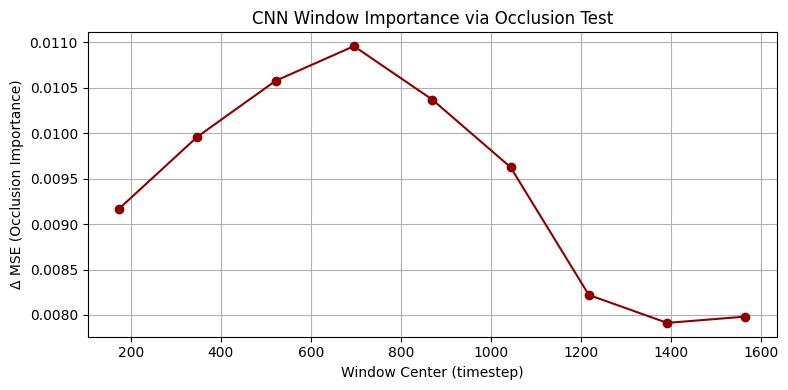

In [6]:
import torch
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# 1️⃣ Load data
# -------------------------------
X = rf_preprocessor.group_and_pad(
    rf_preprocessor.sensor_df, group_col="Experiment_ID"
)[70:, :, :]  # (samples, timesteps, features)

Y = rf_preprocessor.group_and_pad(
    rf_preprocessor.target_df, group_col="Experiment_ID"
)[70:, 20:21, :]  # (samples, 1, output_features)

# -------------------------------
# 2️⃣ Split into train, val, test
# -------------------------------
X_temp, X_test, Y_temp, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, shuffle=True
)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_temp, Y_temp, test_size=0.25, random_state=42, shuffle=True
)

# -------------------------------
# 3️⃣ Convert to torch tensors
# -------------------------------
X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32).squeeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
Y_val_t = torch.tensor(Y_val, dtype=torch.float32).squeeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
Y_test_t = torch.tensor(Y_test, dtype=torch.float32).squeeze(1)

# -------------------------------
# 4️⃣ Initialize CNN model
# -------------------------------
model = TimeSeriesCNN(
    input_size=X.shape[-1],
    seq_len=X.shape[1],
    hidden_channels=64,
    output_size=Y.shape[-1],
    lr=1e-4
)

optimizer = model.optimizer
criterion = model.criterion

# -------------------------------
# 5️⃣ Training loop with early stopping
# -------------------------------
epochs = 100
batch_size = 16
patience = 10
best_val_loss = np.inf
no_improve_count = 0

train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0.0

    permutation = torch.randperm(X_train_t.size(0))
    for i in range(0, X_train_t.size(0), batch_size):
        indices = permutation[i:i + batch_size]
        X_batch, Y_batch = X_train_t[indices], Y_train_t[indices]

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, Y_batch)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

    epoch_train_loss /= (X_train_t.size(0) / batch_size)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        Y_val_pred = model(X_val_t)
        val_loss = criterion(Y_val_pred, Y_val_t).item()
        val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {epoch_train_loss:.6f} | Val Loss: {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve_count = 0
        best_model_state = model.state_dict()
    else:
        no_improve_count += 1
        if no_improve_count >= patience:
            print(f"🛑 Early stopping at epoch {epoch+1}")
            break

# -------------------------------
# 6️⃣ Load best model
# -------------------------------
model.load_state_dict(best_model_state)

# -------------------------------
# 7️⃣ Evaluate on test set
# -------------------------------
model.eval()
with torch.no_grad():
    Y_pred_test = model(X_test_t)
    test_mse = criterion(Y_pred_test, Y_test_t).item()

print(f"\n📊 Final Results:")
print(f"   🟩 Best Validation MSE = {best_val_loss:.6f}")
print(f"   🟥 Test MSE = {test_mse:.6f}")

# -------------------------------
# 8️⃣ Plot training & validation loss
# -------------------------------
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------
# 9️⃣ Occlusion importance scoring
# -------------------------------
seq_len = X_test_t.shape[1]
patch_size = seq_len // 5  # 20% of sequence length
step = patch_size // 2
window_centers = list(range(patch_size // 2, seq_len - patch_size // 2 + 1, step))

model.eval()
with torch.no_grad():
    base_pred = model(X_test_t)
    base_loss = F.mse_loss(base_pred, Y_test_t).item()

print(f"\nBase test MSE: {base_loss:.8f}")

importance_scores, window_positions = [], []

with torch.no_grad():
    for center in window_centers:
        start = center - patch_size // 2
        end = center + patch_size // 2
        if end > seq_len:
            continue

        X_masked = X_test_t.clone()
        X_masked[:, start:end, :] = 0  # occlusion

        masked_pred = model(X_masked)
        masked_loss = F.mse_loss(masked_pred, Y_test_t).item()

        delta_loss = masked_loss - base_loss
        importance_scores.append(delta_loss)
        window_positions.append(center)

        print(f"Window {center:4d} → masked MSE: {masked_loss:.10f}, ΔMSE: {delta_loss:.10f}")

# Plot occlusion importance
plt.figure(figsize=(8, 4))
plt.plot(window_positions, importance_scores, marker='o', color='darkred')
plt.xlabel("Window Center (timestep)")
plt.ylabel("Δ MSE (Occlusion Importance)")
plt.title("CNN Window Importance via Occlusion Test")
plt.grid(True)
plt.tight_layout()
plt.show()


Base test MSE: 0.01290142
Window  174 → masked MSE: 0.0220695995, ΔMSE: 0.0091681760
Window  348 → masked MSE: 0.0228620544, ΔMSE: 0.0099606309
Window  522 → masked MSE: 0.0234781802, ΔMSE: 0.0105767567
Window  696 → masked MSE: 0.0238596369, ΔMSE: 0.0109582134
Window  870 → masked MSE: 0.0232720096, ΔMSE: 0.0103705861
Window 1044 → masked MSE: 0.0225281883, ΔMSE: 0.0096267648
Window 1218 → masked MSE: 0.0211219117, ΔMSE: 0.0082204882
Window 1392 → masked MSE: 0.0208146181, ΔMSE: 0.0079131946
Window 1566 → masked MSE: 0.0208838582, ΔMSE: 0.0079824347


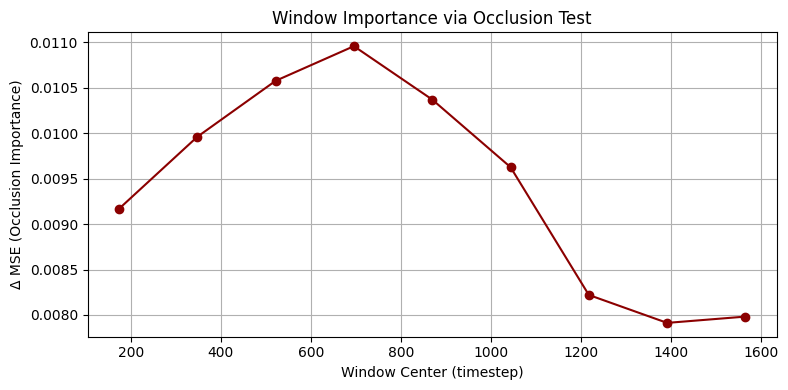

In [7]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def compute_occlusion_importance(model, X_test_t, Y_test_t, patch_ratio=0.2, step_ratio=0.1):
    """
    Compute occlusion importance scores for a time series model.
    
    Args:
        model: PyTorch model for regression.
        X_test_t: torch.Tensor of shape (batch, seq_len, features)
        Y_test_t: torch.Tensor of shape (batch, output_features)
        patch_ratio: fraction of sequence length to mask per window
        step_ratio: fraction of sequence length to slide window
    Returns:
        window_positions: list of center indices for each window
        importance_scores: list of ΔMSE for each window
    """
    seq_len = X_test_t.shape[1]
    patch_size = max(1, int(seq_len * patch_ratio))
    step = max(1, int(seq_len * step_ratio))
    window_centers = list(range(patch_size // 2, seq_len - patch_size // 2 + 1, step))

    model.eval()
    with torch.no_grad():
        base_pred = model(X_test_t)
        base_loss = F.mse_loss(base_pred, Y_test_t).item()
    
    print(f"Base test MSE: {base_loss:.8f}")

    importance_scores, window_positions = [], []

    with torch.no_grad():
        for center in window_centers:
            start = center - patch_size // 2
            end = center + patch_size // 2
            if end > seq_len:
                continue

            X_masked = X_test_t.clone()
            X_masked[:, start:end, :] = 0  # occlude window

            masked_pred = model(X_masked)
            masked_loss = F.mse_loss(masked_pred, Y_test_t).item()
            delta_loss = masked_loss - base_loss

            importance_scores.append(delta_loss)
            window_positions.append(center)

            print(f"Window {center:4d} → masked MSE: {masked_loss:.10f}, ΔMSE: {delta_loss:.10f}")

    # Plot importance
    plt.figure(figsize=(8, 4))
    plt.plot(window_positions, importance_scores, marker='o', color='darkred')
    plt.xlabel("Window Center (timestep)")
    plt.ylabel("Δ MSE (Occlusion Importance)")
    plt.title("Window Importance via Occlusion Test")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return window_positions, importance_scores


# -------------------------------
# Example usage with your CNN
# -------------------------------
window_positions, importance_scores = compute_occlusion_importance(model, X_test_t, Y_test_t)


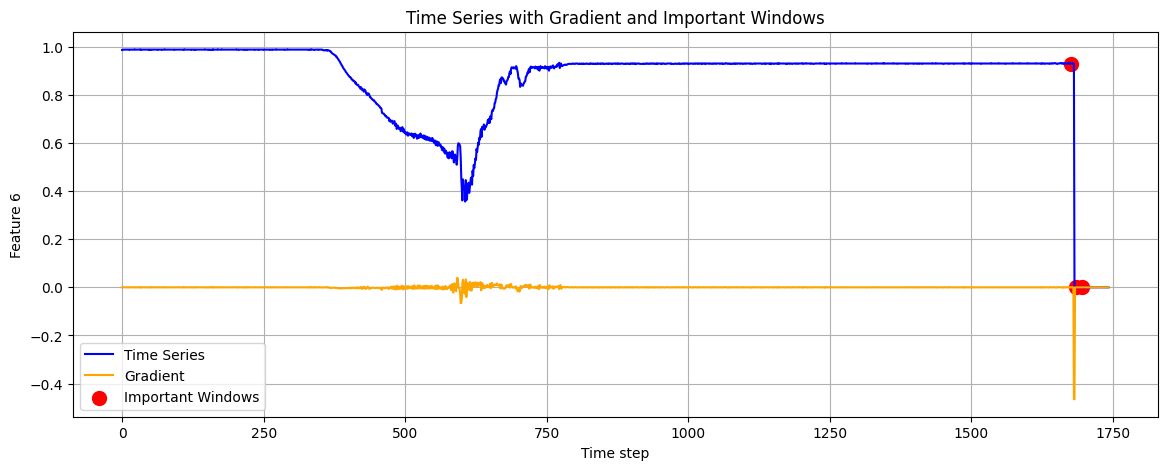

Top 3 important window centers: [1685 1675 1695]


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# -----------------------------
# Choose one sample and one feature
# -----------------------------
sample_idx = 0      # first sample
feature_idx = 6     # feature index to analyze

X_sample = X_test_t[sample_idx, :, feature_idx]  # shape: (seq_len,)
seq_len = X_sample.shape[0]

# -----------------------------
# Compute sliding window importance
# -----------------------------
window_size = 50
step = 10
window_centers = []
importance_scores = []

for start in range(0, seq_len - window_size + 1, step):
    end = start + window_size
    window = X_sample[start:end]

    # Importance metric: variance * mean absolute gradient
    var = np.var(window)
    grad = np.mean(np.abs(np.gradient(window)))
    score = var * grad

    importance_scores.append(score)
    window_centers.append(start + window_size//2)

importance_scores = np.array(importance_scores)
window_centers = np.array(window_centers)

# Find top 3 important windows
top_indices = importance_scores.argsort()[-3:][::-1]
top_windows = window_centers[top_indices]

# -----------------------------
# Compute gradient for plotting
# -----------------------------
X_gradient = np.gradient(X_sample)

# -----------------------------
# Plot original signal and gradient
# -----------------------------
plt.figure(figsize=(14,5))
plt.plot(range(seq_len), X_sample, label='Time Series', color='blue')
plt.plot(range(seq_len), X_gradient, label='Gradient', color='orange')
plt.scatter(top_windows, X_sample[top_windows], color='red', s=100, label='Important Windows')
plt.xlabel("Time step")
plt.ylabel(f"Feature {feature_idx}")
plt.title("Time Series with Gradient and Important Windows")
plt.legend()
plt.grid(True)
plt.show()

print("Top 3 important window centers:", top_windows)


In [129]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# -------------------------------
# Prepare data
# -------------------------------
X = rf_preprocessor.group_and_pad(rf_preprocessor.sensor_df, group_col="Experiment_ID")[:, :, :]
Y = rf_preprocessor.group_and_pad(rf_preprocessor.target_df, group_col="Experiment_ID")[:, 44:45, :]

# Flatten full dataset for baseline
X_full = X.reshape(X.shape[0], -1)
Y_full = Y.reshape(Y.shape[0], -1)

# Split full dataset into train/test
n = len(X_full)
split = int(n * 0.8)
X_train_full, X_test_full = X_full[:split], X_full[split:]
Y_train_full, Y_test_full = Y_full[:split], Y_full[split:]

# -------------------------------
# 1️⃣ Train baseline Random Forest
# -------------------------------
baseline_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
baseline_model.fit(X_train_full, Y_train_full)

# Predict on full test set to compute baseline MSE
Y_pred_full = baseline_model.predict(X_test_full)
baseline_mse = mean_squared_error(Y_test_full, Y_pred_full)
print(f"🏁 Baseline MSE on full dataset = {baseline_mse:.6f}")

# -------------------------------
# 2️⃣ Evaluate baseline on each window
# -------------------------------
window_size = 50
window_starts = list(range(0, X.shape[1], window_size))[:-1]

window_losses, window_positions, rel_errors = [], [], []

n_timesteps, n_features = X.shape[1], X.shape[2]

for window in window_starts:
    X_window = np.zeros_like(X)  # full shape
    X_window[:, window:window + window_size, :] = X[:, window:window + window_size, :]
    
    X_flat = X_window.reshape(X_window.shape[0], -1)
    Y_flat = Y.reshape(Y.shape[0], -1)

    Y_pred = baseline_model.predict(X_flat)
    mse = mean_squared_error(Y_flat, Y_pred)

    window_losses.append(mse)
    window_positions.append(window)
    rel_errors.append(mse / baseline_mse)

    print(f"Window {window:4d} → MSE = {mse:.6f}  |  Relative to baseline = {mse / baseline_mse:.3f}×")

# -------------------------------
# 3️⃣ Analyze results
# -------------------------------
window_losses = np.array(window_losses)
rel_errors = np.array(rel_errors)
window_positions = np.array(window_positions)

best_idx = np.argmin(window_losses)
best_window = window_positions[best_idx]
best_loss = window_losses[best_idx]
best_rel = rel_errors[best_idx]

print(f"\n✅ Most predictable window starts at timestep {best_window}, MSE={best_loss:.6f}, Relative to baseline = {best_rel:.3f}×")

# -------------------------------
# 4️⃣ Plot results
# -------------------------------
plt.figure(figsize=(10, 5))
plt.plot(window_positions, window_losses, marker='o', label='Window MSE')
plt.axhline(baseline_mse, color='gray', linestyle='--', label='Baseline MSE')
plt.axvline(best_window, color='r', linestyle='--', label=f'Best Window ({best_window})')
plt.title("Baseline Random Forest - MSE per Window")
plt.xlabel("Window Start Time (index)")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(X[100,:1600,:])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


true_vals = Y_test_full[:, 0]
pred_vals = Y_pred_full[:, 0]
plt.figure(figsize=(12, 5))
plt.plot(true_vals, label="True Y", color="blue")
plt.plot(pred_vals, label="Predicted Y (baseline)", color="red", linestyle="--")
plt.title("Baseline Random Forest Predictions vs True Values")
plt.xlabel("Test Sample Index")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

divide the angles

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# --- Load your dataset ---
# -------------------------
torch.manual_seed(42)

# Example dataset extraction (replace with your rf_preprocessor calls)
# Note: You'll need to define rf_preprocessor or replace these lines with your actual data loading
X = rf_preprocessor.group_and_pad(
    rf_preprocessor.sensor_df, group_col="Experiment_ID"
)[70:, ::10, 2:]  # shape: (samples, timesteps, features)
y = rf_preprocessor.group_and_pad(
    rf_preprocessor.target_df, group_col="Experiment_ID"
)[70:, :-2, 2:3]  # shape: (samples, timesteps_to_predict, 1)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

samples, timesteps, n_features = X.shape
output_size = y.shape[1]

# Flatten input for MLP
X_flat = X.view(samples, timesteps * n_features)
y_flat = y.squeeze(-1)
print("X_flat:", X_flat.shape, "y_flat:", y_flat.shape)

# --- Define a larger / deeper MLP ---
class DeepMLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super().__init__()
        layers = []
        prev_size = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.ReLU())  # Add activation explicitly
            prev_size = h
        self.hidden_layers = nn.Sequential(*layers)  # Use Sequential for cleaner code
        self.out = nn.Linear(prev_size, output_size)

    def forward(self, x):
        x = self.hidden_layers(x)
        out = self.out(x)
        return out, []  # Return empty list for compatibility

# --- Increase depth and width ---
hidden_sizes = [256, 512, 256, 128, 64]  # deeper and wider
input_size = X_flat.shape[1]  # Use flattened input size
output_size = y_flat.shape[1]  # Use flattened output size

model = DeepMLP(input_size=input_size, hidden_sizes=hidden_sizes, output_size=output_size)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# --- Training ---
model.train()
for epoch in range(500):  # you can increase epochs if needed
    optimizer.zero_grad()
    output, _ = model(X_flat)
    loss = criterion(output, y_flat)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}: MSE={loss.item():.6f}")

# -------------------------
# --- Input Importance (interpretable) ---
# -------------------------
def compute_input_importance_2d(model, x_sample, target_idx=0, timesteps=None, n_features=None):
    """
    Compute input importance for a single output neuron.
    Returns a 2D array (timesteps x features) instead of flattened vector.
    """
    model.eval()  # Set model to evaluation mode
    
    if timesteps is None or n_features is None:
        raise ValueError("timesteps and n_features must be provided")
    
    x = x_sample.clone().detach().requires_grad_(True)
    output, _ = model(x)
    target_output = output[0, target_idx]
    
    # Zero gradients before backward pass
    if x.grad is not None:
        x.grad.zero_()
        
    target_output.backward()
    grads = x.grad.detach().numpy().reshape(timesteps, n_features)
    importance = np.abs(grads)
    return importance

# Suppose these are your sensor feature names
feature_names = rf_preprocessor.sensor_df.columns[2:]  # 3 features selected

def plot_input_importance_2d(importance, feature_names=None, title="Input Importance (features x timesteps)"):
    """
    Plot a heatmap of importance for each feature and timestep.
    X-axis: timesteps
    Y-axis: feature names (or indices if feature_names is None)
    """
    plt.figure(figsize=(10, 5))
    # transpose so features are rows and timesteps are columns
    plt.imshow(importance.T, aspect='auto', cmap='viridis', origin='lower')
    plt.colorbar(label="|∂output/∂input|")
    plt.xlabel("Timestep")
    
    if feature_names is not None:
        plt.yticks(ticks=np.arange(len(feature_names)), labels=feature_names)
    else:
        plt.ylabel("Feature index")
    
    plt.title(title)
    plt.tight_layout()
    plt.show()


X_flat: torch.Size([245, 2450]) y_flat: torch.Size([245, 45])
Epoch 50: MSE=0.003306
Epoch 100: MSE=0.001384
Epoch 150: MSE=0.001035
Epoch 200: MSE=0.000979
Epoch 250: MSE=0.001067
Epoch 300: MSE=0.000884
Epoch 350: MSE=0.000898
Epoch 400: MSE=0.000827
Epoch 450: MSE=0.000800
Epoch 500: MSE=0.000766


In [4]:
output_idx = 0
x_sample = X_flat[sample_idx].unsqueeze(0)

importance_2d = compute_input_importance_2d(model, x_sample, target_idx=output_idx,
                                             timesteps=timesteps, n_features=n_features)
plot_input_importance_2d(importance_2d, feature_names, title=f"Output neuron {output_idx} importance")

NameError: name 'sample_idx' is not defined

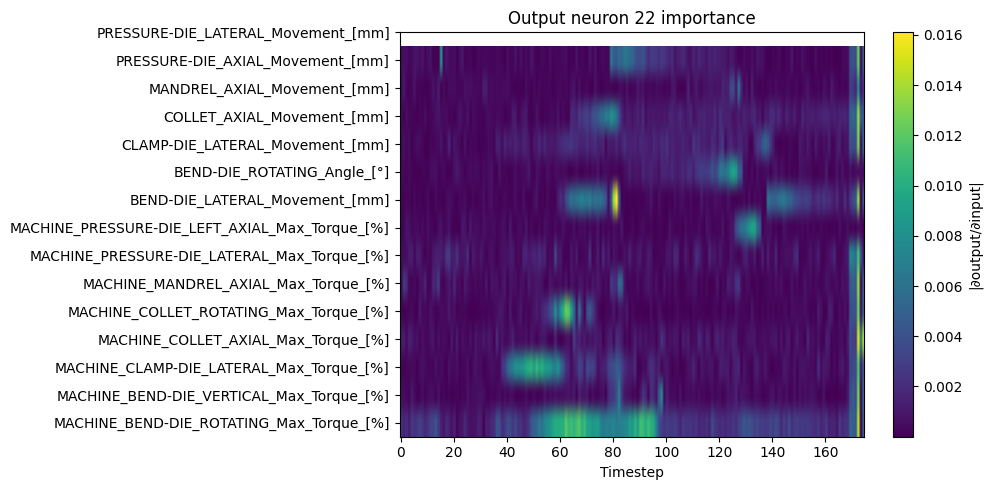

In [ ]:
output_idx = 22
x_sample = X_flat[sample_idx].unsqueeze(0)

importance_2d = compute_input_importance_2d(model, x_sample, target_idx=output_idx,
                                             timesteps=timesteps, n_features=n_features)
plot_input_importance_2d(importance_2d, feature_names, title=f"Output neuron {output_idx} importance")

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import mutual_info_regression, f_regression
from sklearn.preprocessing import KBinsDiscretizer
from ipywidgets import interact, IntSlider, Dropdown

# --- Load data ---
# X: shape (samples, timesteps, features)
# y: shape (samples, timesteps_to_predict, features)
X = rf_preprocessor.group_and_pad(rf_preprocessor.sensor_df, group_col="Experiment_ID")[70:, ::10, 2:]
y = rf_preprocessor.group_and_pad(rf_preprocessor.target_df, group_col="Experiment_ID")[70:, :-2, 1:]
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

timesteps = X.shape[1]
n_features = X.shape[2]

# --- Use true feature names ---
feature_names = [col for col in rf_preprocessor.sensor_df.columns[2:]]

# --- Importance methods ---
def pearson_importance(X, y_target):
    importance = np.zeros((timesteps, n_features))
    for t in range(timesteps):
        for f in range(n_features):
            importance[t, f] = abs(np.corrcoef(X[:, t, f], y_target)[0, 1])
    return importance

def spearman_importance(X, y_target):
    importance = np.zeros((timesteps, n_features))
    for t in range(timesteps):
        for f in range(n_features):
            corr, _ = spearmanr(X[:, t, f], y_target)
            importance[t, f] = abs(corr)
    return importance

def mutual_info_importance(X, y_target):
    importance = np.zeros((timesteps, n_features))
    for t in range(timesteps):
        for f in range(n_features):
            mi = mutual_info_regression(X[:, t, f].reshape(-1, 1), y_target, random_state=42)
            importance[t, f] = mi[0]
    return importance

def regression_importance(X, y_target):
    importance = np.zeros((timesteps, n_features))
    for t in range(timesteps):
        model = LinearRegression()
        model.fit(X[:, t, :], y_target)
        importance[t, :] = np.abs(model.coef_)
    return importance

def anova_importance(X, y_target, n_bins=4):
    discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
    y_discrete = discretizer.fit_transform(y_target.reshape(-1, 1)).ravel()
    importance = np.zeros((timesteps, n_features))
    for t in range(timesteps):
        f_stats, _ = f_regression(X[:, t, :], y_discrete)
        importance[t, :] = f_stats
    return importance

def partial_corr_importance(X, y_target):
    importance = np.zeros((timesteps, n_features))
    for t in range(timesteps):
        X_t = X[:, t, :]
        data = np.column_stack((y_target, X_t))
        corr_matrix = np.corrcoef(data, rowvar=False)
        corr_matrix = np.nan_to_num(corr_matrix, nan=0.0)
        try:
            inv_corr = np.linalg.inv(corr_matrix)
        except np.linalg.LinAlgError:
            corr_matrix += np.eye(corr_matrix.shape[0]) * 1e-6
            inv_corr = np.linalg.inv(corr_matrix)
        partial_corr = np.zeros(n_features)
        for f in range(n_features):
            partial_corr[f] = -inv_corr[0, f + 1] / np.sqrt(inv_corr[0, 0] * inv_corr[f + 1, f + 1])
        importance[t, :] = np.abs(partial_corr)
    return importance

methods = {
    "Pearson": pearson_importance,
    "Spearman": spearman_importance,
    "Mutual Info": mutual_info_importance,
    "Regression": regression_importance,
    "ANOVA F-Test": anova_importance,
    "Partial Corr": partial_corr_importance
}

# --- Plot function ---
def plot_importance(target_feature_idx=0, target_timestep=0, method_name="Pearson"):
    y_target = y[:, target_timestep, target_feature_idx]
    importance = methods[method_name](X, y_target)
    
    plt.figure(figsize=(12, 5))
    plt.imshow(importance.T, aspect='auto', cmap='viridis', origin='lower')
    plt.colorbar(label="Importance")
    plt.xlabel("Timestep")
    plt.ylabel("Feature")
    plt.yticks(ticks=np.arange(len(feature_names)), labels=feature_names)
    most_effective_timestep = np.argmax(np.sum(importance, axis=1))
    plt.title(f"{method_name} Importance (Most effective timestep: {most_effective_timestep})")
    plt.tight_layout()
    plt.show()

# --- Interactive widget ---
interact(
    plot_importance,
    target_feature_idx=IntSlider(min=0, max=y.shape[2]-1, step=1, value=0),
    target_timestep=IntSlider(min=0, max=y.shape[1]-1, step=1, value=0),
    method_name=Dropdown(options=list(methods.keys()), value="Pearson")
)


interactive(children=(IntSlider(value=0, description='target_feature_idx', max=3), IntSlider(value=0, descript…

<function __main__.plot_importance(target_feature_idx=0, target_timestep=0, method_name='Pearson')>


=== Method: mutual_info ===
Most effective timestep (DCT): 172
Most effective timestep (FFT): 164


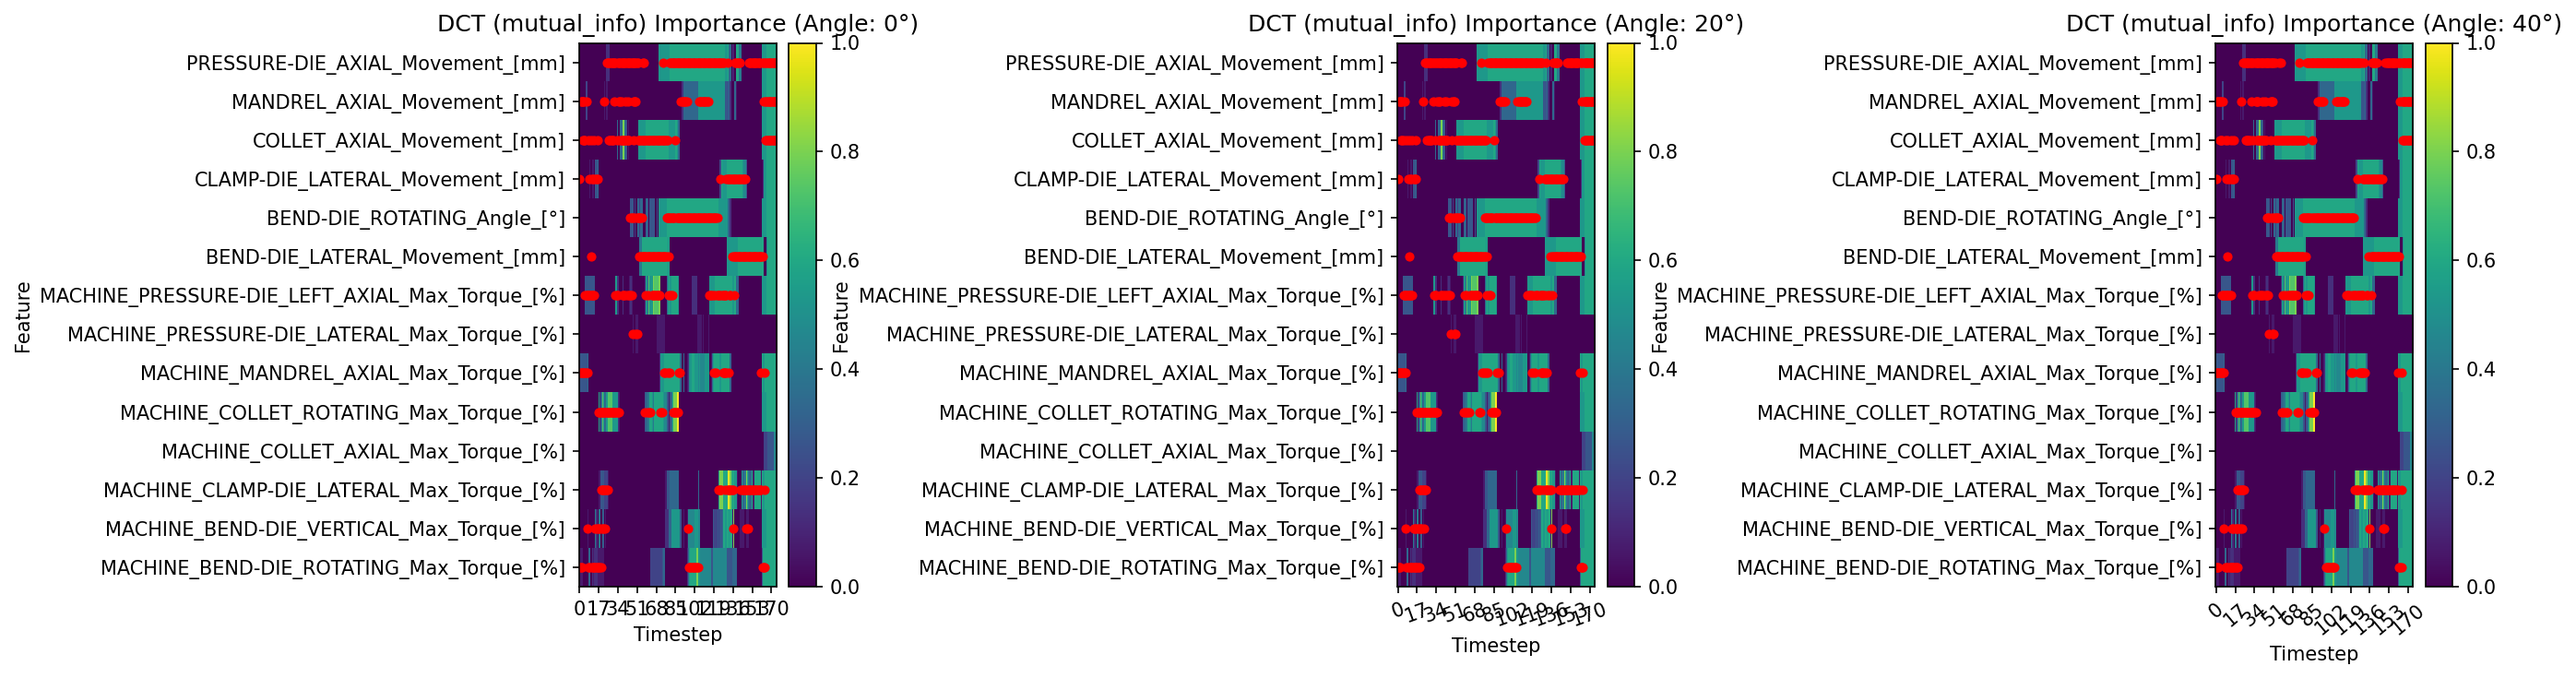

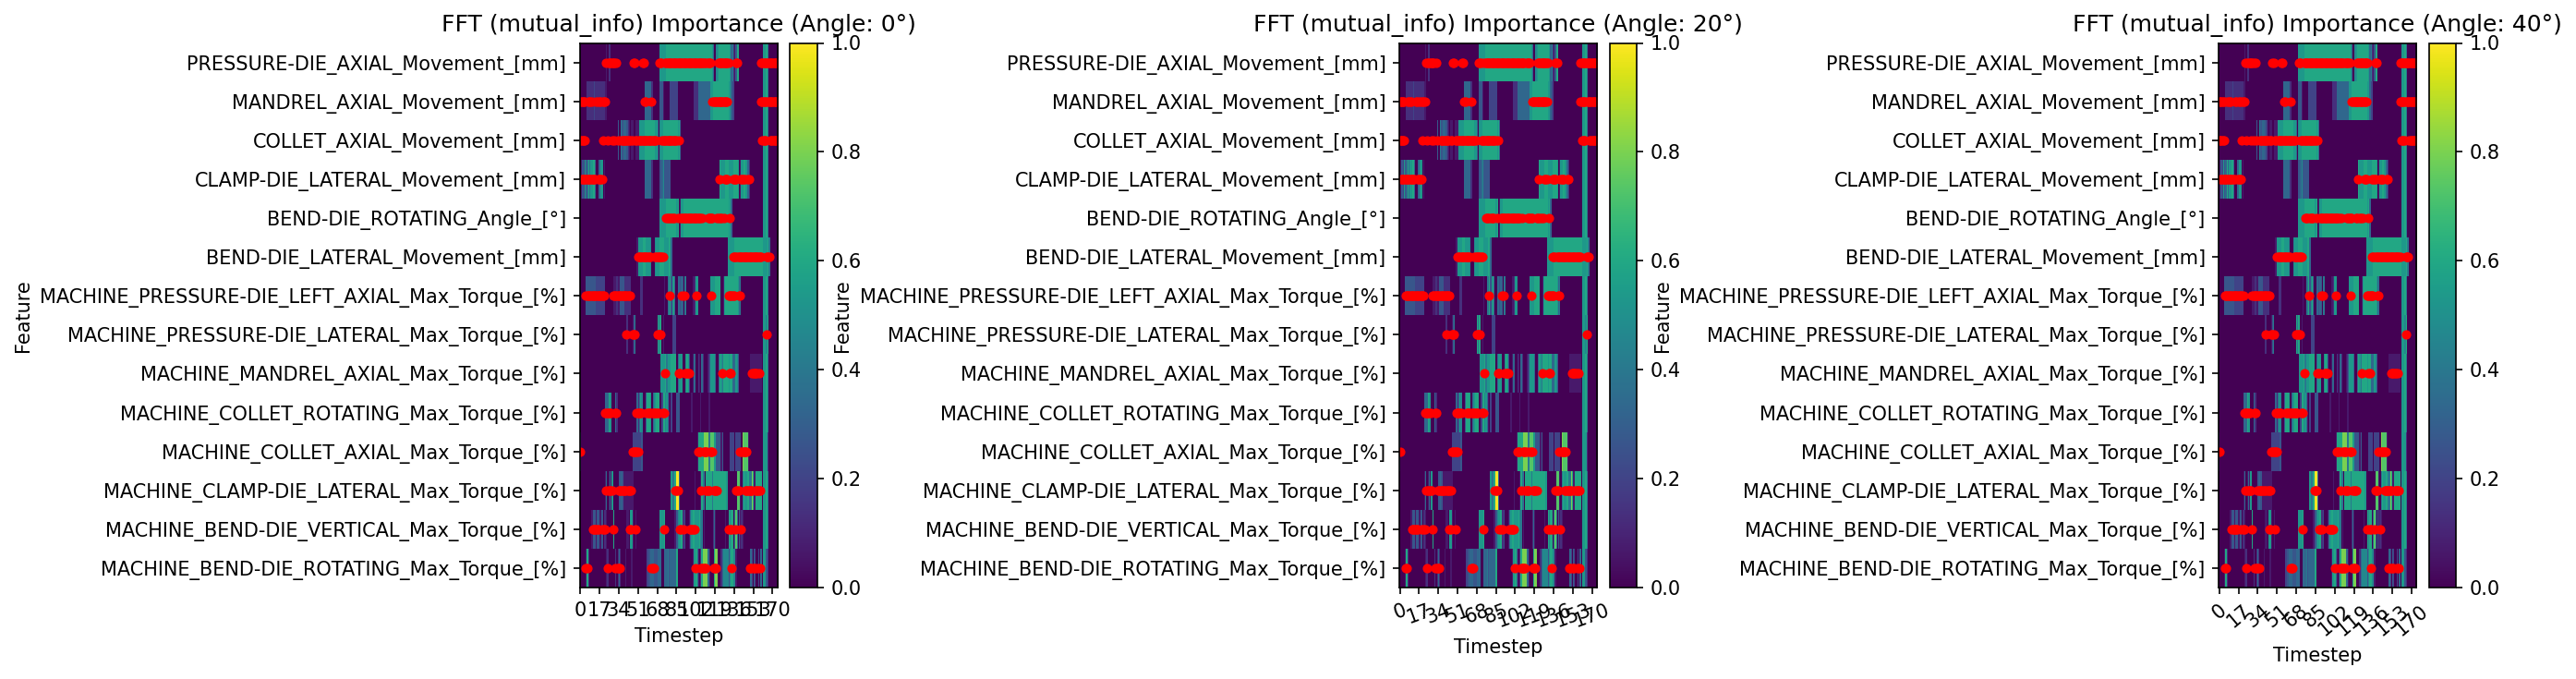


=== Method: correlation ===


/home/arman/Documents/univrsity/Master/Master these 2025/tube-geometry-prediction/tube-venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/arman/Documents/univrsity/Master/Master these 2025/tube-geometry-prediction/tube-venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/arman/Documents/univrsity/Master/Master these 2025/tube-geometry-prediction/tube-venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/arman/Documents/univrsity/Master/Master these 2025/tube-geometry-prediction/tube-venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/arman/Documents/univrsity/Master/Master these 2025/tube-geometry-prediction/tu

Most effective timestep (DCT): 0
Most effective timestep (FFT): 0


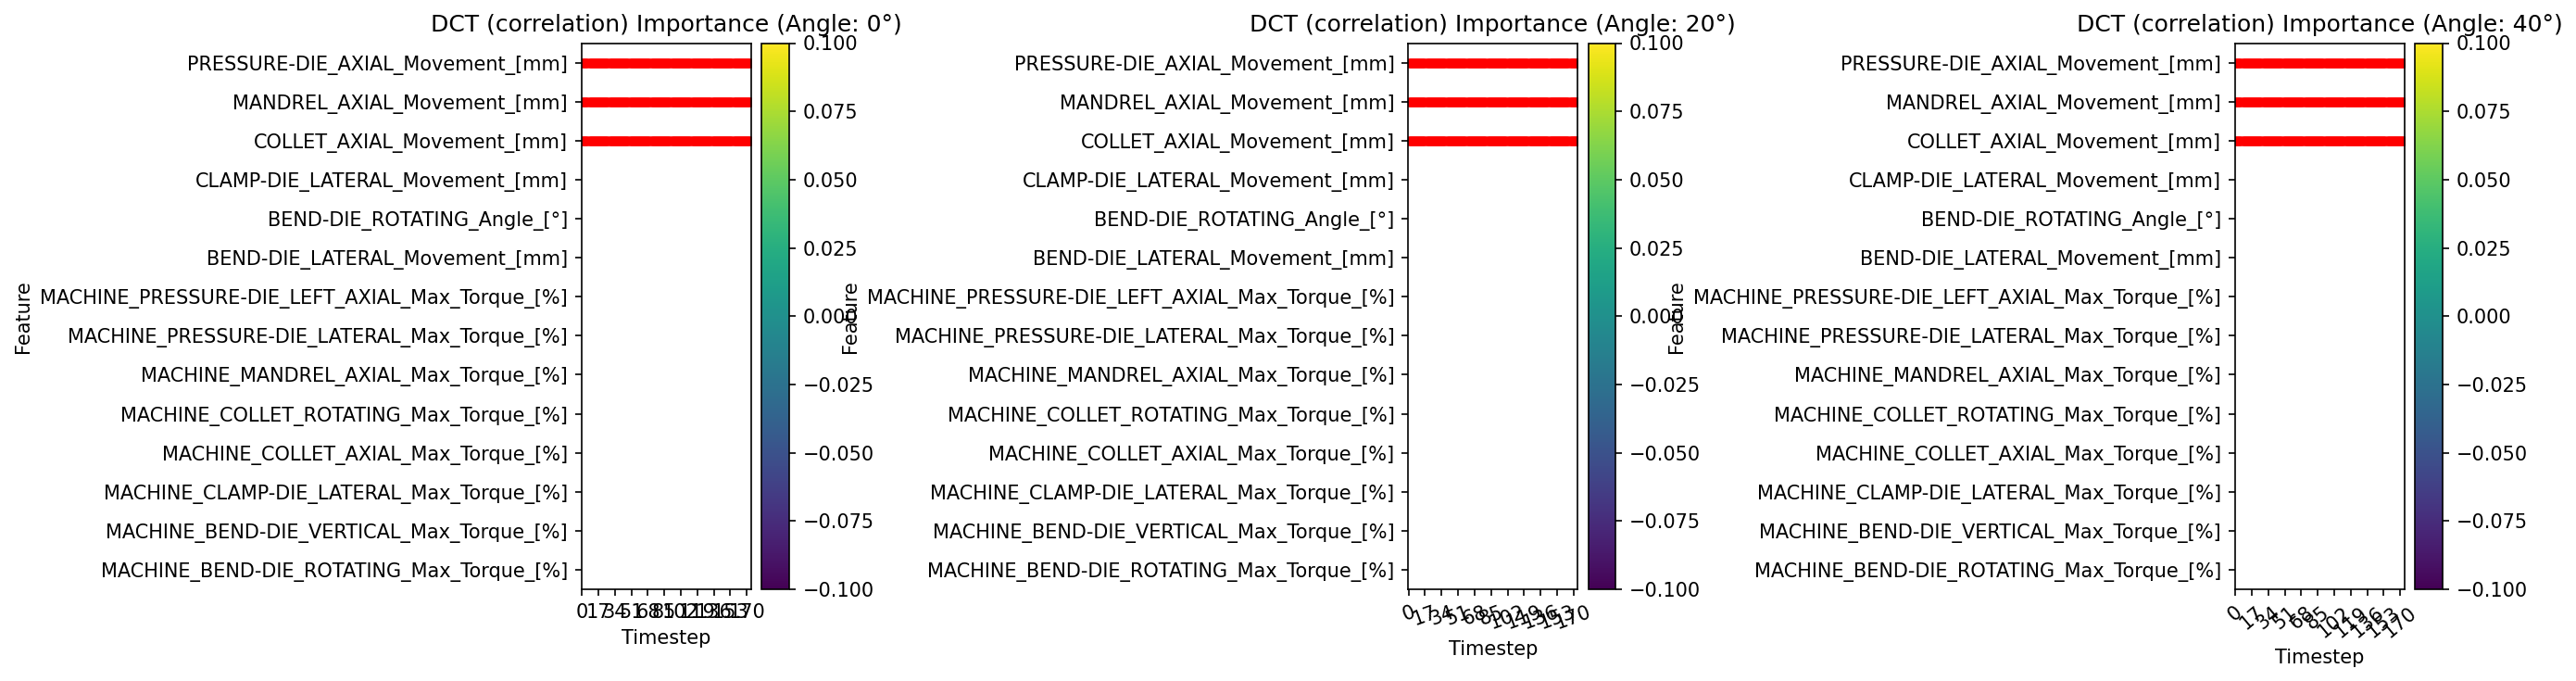

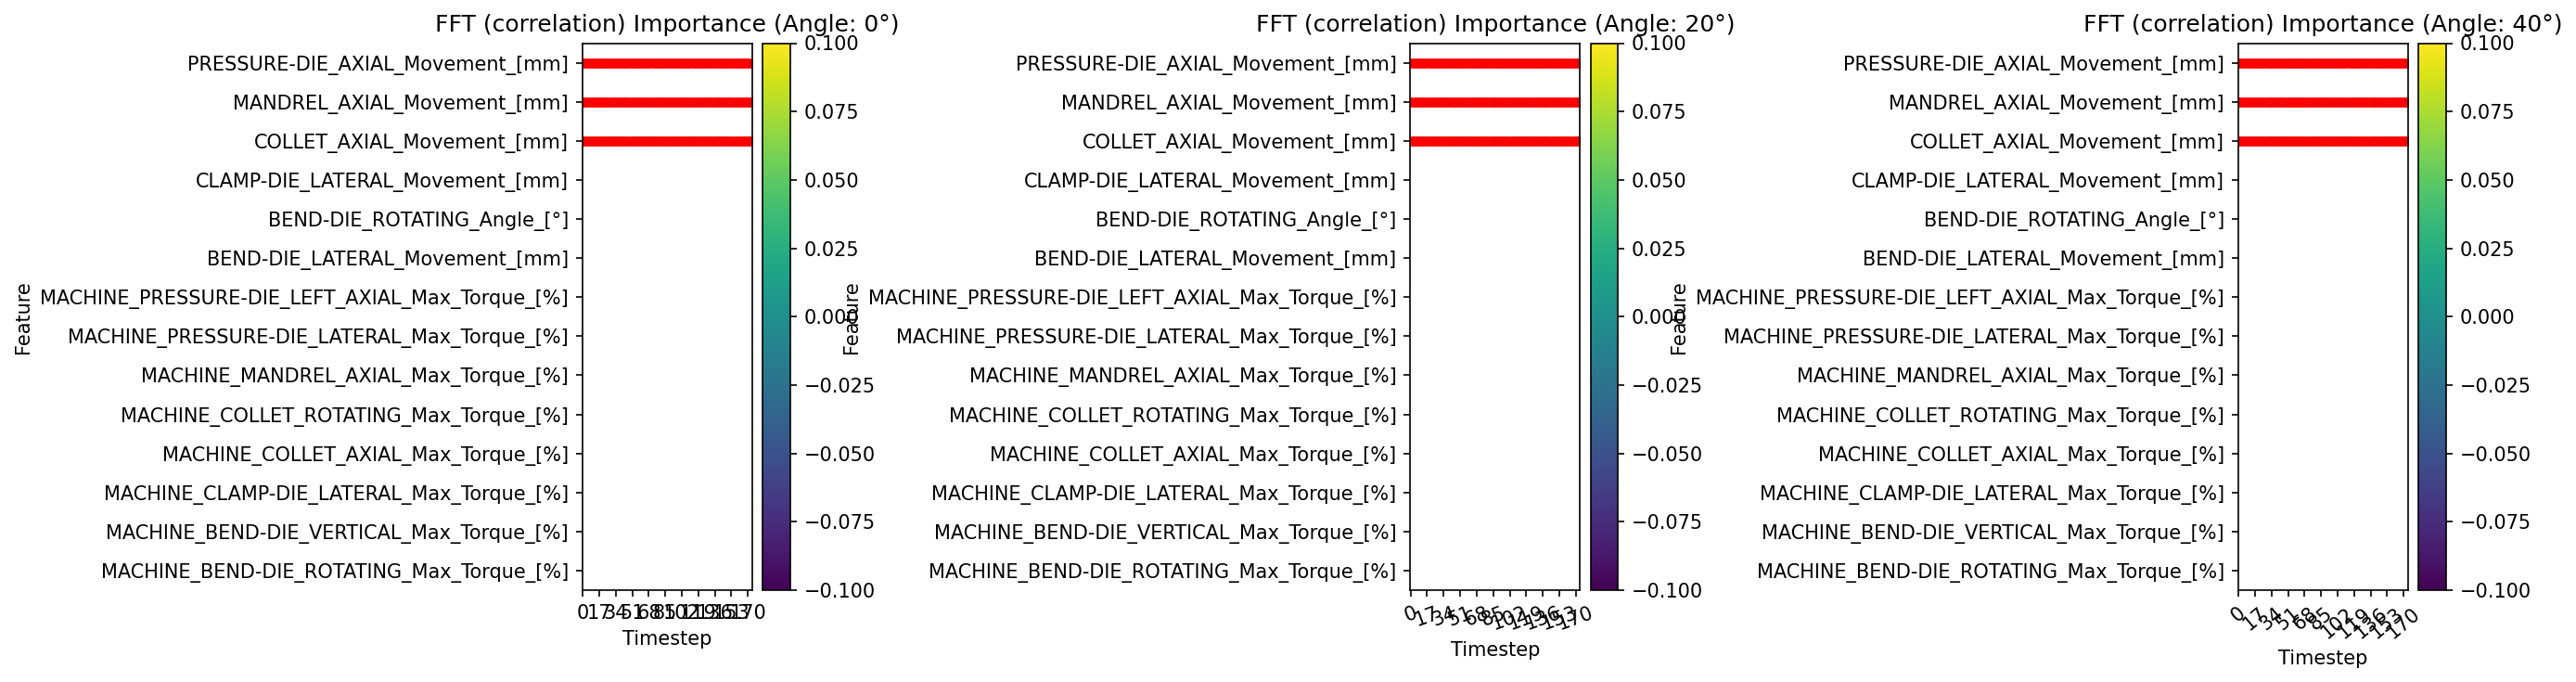


=== Method: f_value ===
Most effective timestep (DCT): 132
Most effective timestep (FFT): 164


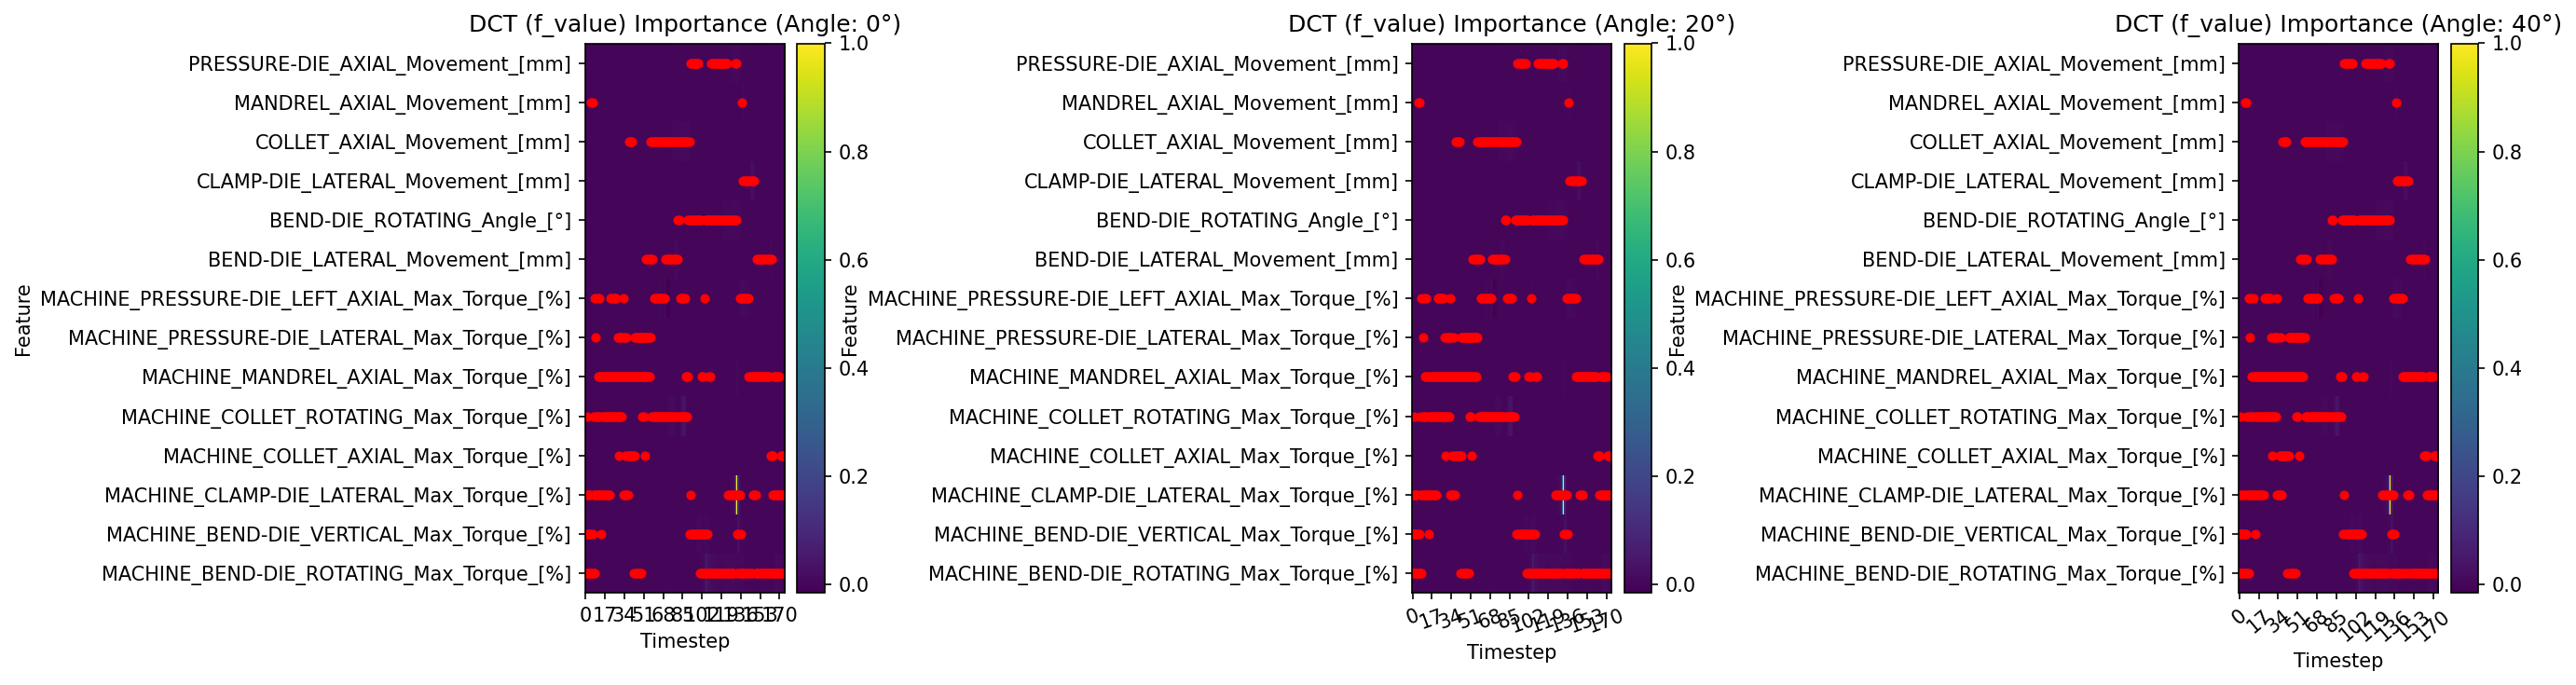

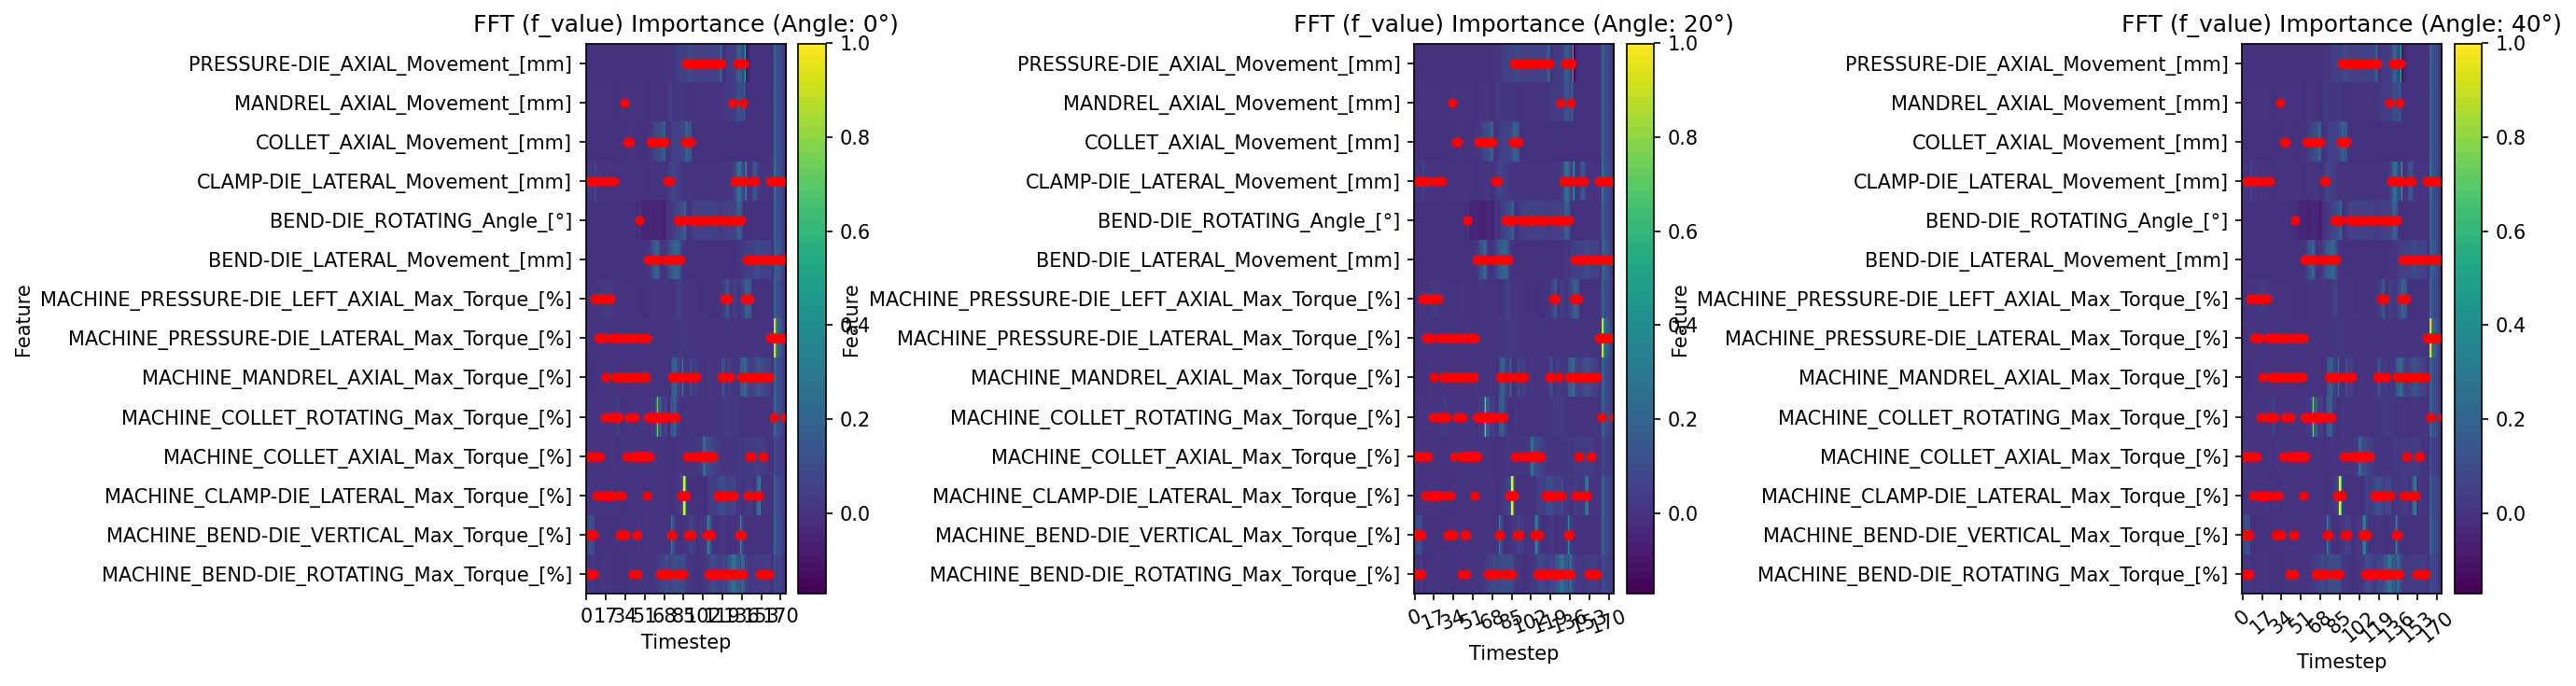


=== Method: rf ===
Most effective timestep (DCT): 70
Most effective timestep (FFT): 70


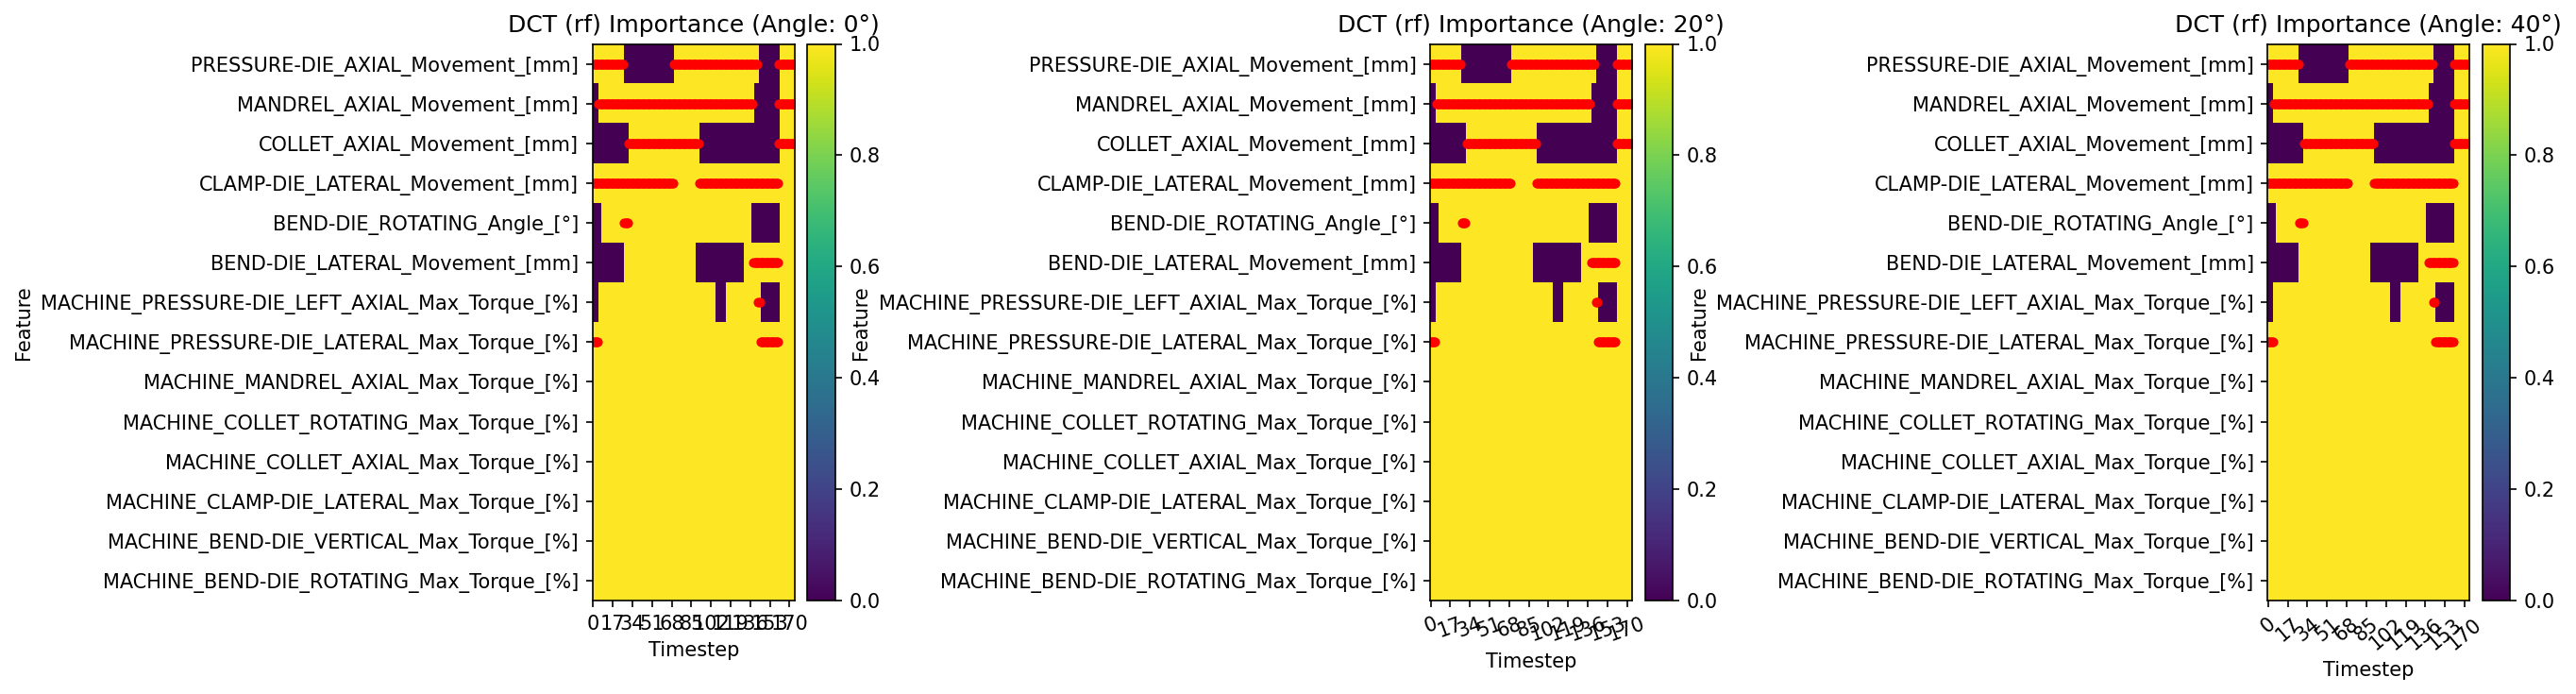

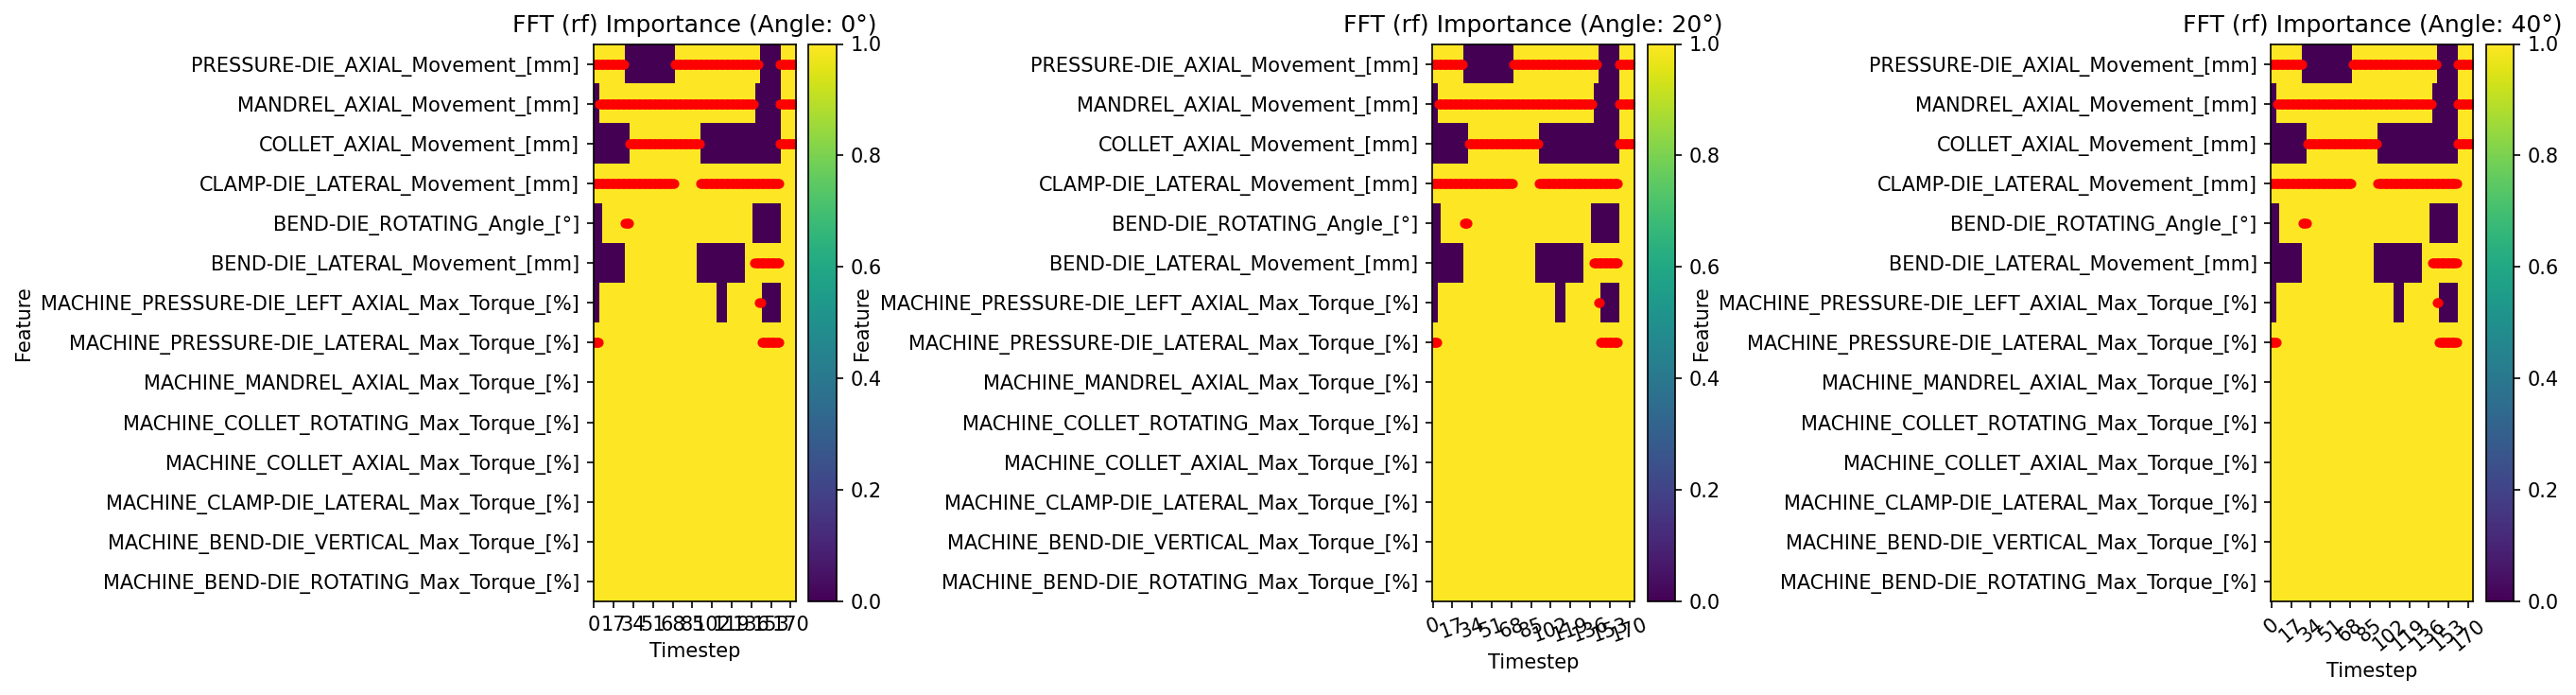

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression, f_regression
from sklearn.ensemble import RandomForestRegressor
from scipy.fft import dct
from joblib import Parallel, delayed

# -----------------------------
# Prepare data
# -----------------------------
X = rf_preprocessor.group_and_pad(rf_preprocessor.sensor_df, group_col="Experiment_ID")[70:75, ::10, 2:]
y = rf_preprocessor.group_and_pad(rf_preprocessor.target_df, group_col="Experiment_ID")[70:75, :-2, 1:2]
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

y_target = y[:, 20, 0]  # target at specific timestep

window_size = 16
half_window = window_size // 2

timesteps = X.shape[1]
n_features = X.shape[2]

feature_names = [col for col in rf_preprocessor.sensor_df.columns[2:]]

top_k = 3  # number of features to highlight

# -----------------------------
# Feature importance functions
# -----------------------------
def feature_importance_dct(X_window, y_target, f, method_type="mutual_info"):
    energy = np.sum(dct(X_window[:, :, f], type=2, norm='ortho')**2, axis=1)
    return compute_importance_method(energy, y_target, method_type)

def feature_importance_fft(X_window, y_target, f, method_type="mutual_info"):
    magnitude = np.abs(np.fft.fft(X_window[:, :, f], axis=1))
    # average across frequency components
    avg_magnitude = magnitude.mean(axis=1)
    return compute_importance_method(avg_magnitude, y_target, method_type)

def compute_importance_method(feature_array, y_target, method_type="mutual_info"):
    if method_type == "mutual_info":
        return mutual_info_regression(feature_array.reshape(-1,1), y_target, random_state=42)[0]
    elif method_type == "f_value":
        return f_regression(feature_array.reshape(-1,1), y_target)[0][0]
    elif method_type == "rf":
        model = RandomForestRegressor(n_estimators=50, random_state=42)
        model.fit(feature_array.reshape(-1,1), y_target)
        return model.feature_importances_[0]
    else:
        raise ValueError(f"Unknown method_type: {method_type}")

# -----------------------------
# Compute importance matrix
# -----------------------------
def compute_importance_matrix(X, y_target, timesteps, n_features, window_size, method="dct", method_type="mutual_info"):
    importance = np.zeros((timesteps, n_features))
    half_window = window_size // 2
    
    for t in range(timesteps):
        start = max(0, t - half_window)
        end = min(timesteps, t + half_window + 1)
        X_window = X[:, start:end, :]
        
        if method == "dct":
            results = Parallel(n_jobs=-1)(delayed(feature_importance_dct)(X_window, y_target, f, method_type)
                                          for f in range(n_features))
        elif method == "fft":
            results = Parallel(n_jobs=-1)(delayed(feature_importance_fft)(X_window, y_target, f, method_type)
                                          for f in range(n_features))
        else:
            raise ValueError(f"Unknown method: {method}")
        
        importance[t, :] = results
    
    # normalize
    importance /= np.max(importance)
    return importance

# -----------------------------
# Plotting function: multiple subplots
# -----------------------------
def plot_importance_subplots(importance, feature_names, title="Importance", angles=[0, 20, 40], top_k=3):
    n_angles = len(angles)
    fig, axes = plt.subplots(1, n_angles, figsize=(6*n_angles, 5), dpi=150)
    
    for i, angle in enumerate(angles):
        ax = axes[i]
        im = ax.imshow(importance.T, aspect='auto', cmap='viridis', origin='lower', interpolation='nearest')
        ax.set_title(f"{title} (Angle: {angle}°)")
        ax.set_xlabel("Timestep")
        ax.set_ylabel("Feature")
        ax.set_yticks(np.arange(len(feature_names)))
        ax.set_yticklabels(feature_names)
        ax.set_xticks(np.arange(0, importance.shape[0], max(1, importance.shape[0]//10)))
        ax.set_xticklabels(np.arange(0, importance.shape[0], max(1, importance.shape[0]//10)), rotation=angle)
        
        # highlight top-K features per timestep
        for t in range(importance.shape[0]):
            top_idx = np.argsort(importance[t, :])[-top_k:]
            ax.scatter([t]*top_k, top_idx, color='red', s=15, marker='o')
        
        fig.colorbar(im, ax=ax)
    
    plt.tight_layout()
    plt.show()

# -----------------------------
# Compute and plot
# -----------------------------
methods = ["mutual_info", "rf"]
for method_type in methods:
    print(f"\n=== Method: {method_type} ===")
    
    dct_imp = compute_importance_matrix(X, y_target, timesteps, n_features, window_size, method="dct", method_type=method_type)
    fft_imp = compute_importance_matrix(X, y_target, timesteps, n_features, window_size, method="fft", method_type=method_type)
    
    # most effective timestep
    most_dct = np.argmax(np.sum(dct_imp, axis=1))
    most_fft = np.argmax(np.sum(fft_imp, axis=1))
    print(f"Most effective timestep (DCT): {most_dct}")
    print(f"Most effective timestep (FFT): {most_fft}")
    
    # plot
    plot_importance_subplots(dct_imp, feature_names, title=f"DCT ({method_type}) Importance", top_k=top_k)
    plot_importance_subplots(fft_imp, feature_names, title=f"FFT ({method_type}) Importance", top_k=top_k)
